# 02 — Markov Chains
**Week 2 | Mathematical Foundations for RL**

Markov chains are the mathematical backbone of MDPs. The **Markov property** states:

$$P(s_{t+1} | s_t, s_{t-1}, ..., s_0) = P(s_{t+1} | s_t)$$

The future depends only on the present — not the history. This is what makes RL tractable.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)

## 1. A Simple 3-State Markov Chain
States: Sunny (0), Cloudy (1), Rainy (2)

In [9]:
# Transition matrix T[i,j] = P(next=j | current=i)
T = np.array([
[0.6,	0.2,	0.1,	0.1],		#	from	Sunny
[0.3,	0.4,	0.2,	0.1],		#	from	Cloudy
[0.1,	0.3,	0.4,	0.2],		#	from	Rainy
[0.1,	0.2,	0.3,	0.4],		#	from	Stormy
])

state_names = ['Sunny', 'Cloudy', 'Rainy','Stormy']

# Verify rows sum to 1
assert np.allclose(T.sum(axis=1), 1), "Rows must sum to 1!"
print("Transition matrix:")
print(T)

Transition matrix:
[[0.6 0.2 0.1 0.1]
 [0.3 0.4 0.2 0.1]
 [0.1 0.3 0.4 0.2]
 [0.1 0.2 0.3 0.4]]


## 2. Simulate a Trajectory

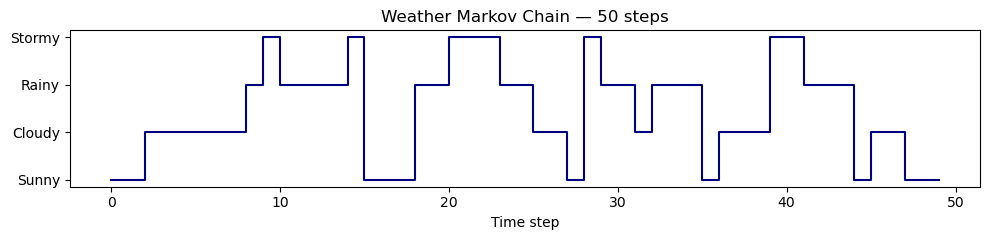

In [10]:
def simulate_markov(T, start_state, n_steps):
    trajectory = [start_state]
    state = start_state
    for _ in range(n_steps - 1):
        state = np.random.choice(len(T), p=T[state])
        trajectory.append(state)
    return np.array(trajectory)

traj = simulate_markov(T, start_state=0, n_steps=50)

plt.figure(figsize=(10, 2.5))
colors = ['gold', 'skyblue', 'steelblue']
plt.step(range(len(traj)), traj, where='post', color='navy', linewidth=1.5)
plt.yticks([0,1,2,3], state_names)
plt.xlabel('Time step'); plt.title('Weather Markov Chain — 50 steps')
plt.tight_layout(); plt.show()

## 3. Stationary Distribution
After many steps, the chain settles into a **stationary distribution** π where π = π · T.

We can find it as the left eigenvector of T corresponding to eigenvalue 1.

In [11]:
# Analytical: left eigenvector
eigenvalues, eigenvectors = np.linalg.eig(T.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))  # eigenvalue closest to 1
stationary_analytical = np.real(eigenvectors[:, idx])
stationary_analytical /= stationary_analytical.sum()
print("Analytical stationary distribution:", np.round(stationary_analytical, 4))

# Empirical: simulate 100,000 steps
long_traj = simulate_markov(T, start_state=0, n_steps=100_000)
stationary_empirical = np.bincount(long_traj) / len(long_traj)
print("Empirical  stationary distribution:", np.round(stationary_empirical, 4))

Analytical stationary distribution: [0.3117 0.2791 0.2331 0.1762]
Empirical  stationary distribution: [0.3149 0.2746 0.2343 0.1762]


# Ans3) below cell!

In [16]:
#	Piiii
lhs	=	stationary_analytical	@	T
assert	np.allclose(lhs,	stationary_analytical),	"π	is	NOT	stationary!"
print("π@T= ",	np.round(lhs,	6))
print("π= ",	np.round(stationary_analytical,	6))
print("	π@T	==	π confirmed")

π@T=  [0.311653 0.279133 0.233062 0.176152]
π=  [0.311653 0.279133 0.233062 0.176152]
	π@T	==	π confirmed


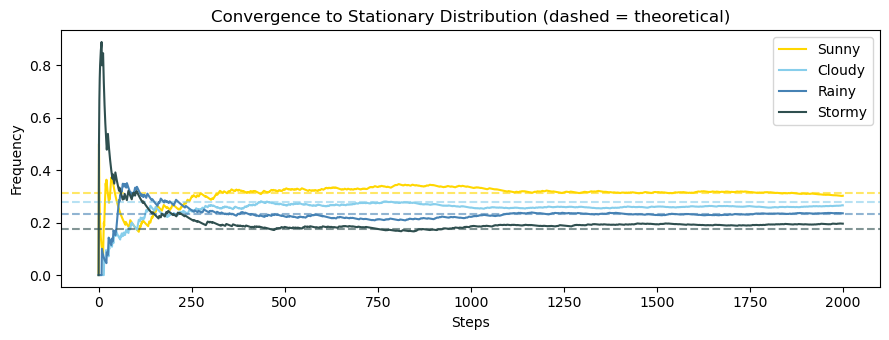

In [12]:
# Visualise convergence to stationary distribution
n_steps = 2000
state_freq = np.zeros((n_steps, 4))
traj_long = simulate_markov(T, start_state=0, n_steps=n_steps)
for t in range(1, n_steps):
    state_freq[t] = np.bincount(traj_long[:t+1], minlength=4) / (t+1)

fig, ax = plt.subplots(figsize=(9, 3.5))
colors_ = ['gold', 'skyblue', 'steelblue','darkslategray']
for i, (name, c) in enumerate(zip(state_names, colors_)):
    ax.plot(state_freq[:, i], color=c, linewidth=1.5, label=name)
    ax.axhline(stationary_analytical[i], color=c, linestyle='--', alpha=0.6)
ax.set_xlabel('Steps'); ax.set_ylabel('Frequency')
ax.set_title('Convergence to Stationary Distribution (dashed = theoretical)')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Matrix Power — Another View
P(state at t=n | start state) = T^n · initial_distribution

In [13]:
init = np.array([1.0, 0.0, 0.0, 0.0])  # start in Sunny
print(f"t=0:  {init}")
Tn = T.copy()
for t in [1, 5, 10, 50]:
    Tn_power = np.linalg.matrix_power(T, t)
    dist = init @ Tn_power
    print(f"t={t:<3}: {np.round(dist, 4)}")  # should converge to stationary

t=0:  [1. 0. 0. 0.]
t=1  : [0.6 0.2 0.1 0.1]
t=5  : [0.324  0.2767 0.2269 0.1724]
t=10 : [0.3119 0.2791 0.2329 0.1761]
t=50 : [0.3117 0.2791 0.2331 0.1762]


## ✅ Exercises
1. Change the transition matrix so that once it rains, it always rains next (absorbing state). What happens to the stationary distribution?
2. Add a 4th state (Stormy) to the chain. Update T, make sure rows sum to 1, and re-run.
3. **Challenge**: prove to yourself that `π @ T == π` for the stationary distribution you computed above. Write the assertion.

Ans1) Stationary	distribution	becomes	[0,	0,	1].	Every
trajectory	eventually	falls	into	Rainy	and	never	leaves	—	Rainy	is	an
absorbing	state,	and	since	it’s	reachable	from	Sunny	and	Cloudy,	all
long-run	probability	mass	drains	into	it.	In	the	convergence	plot,
Rainy’s	frequency	climbs	to	1.

Ans 2)Everything	runs	identically	with	4	states;	you	get	a	4
component	stationary	distribution	and	4	convergence	lines.